# Low Fidelity Neural Network
Neural Network which uses LF dataset and exploits the Low fidelity component of the MF model. The NN is tested also on the HF test set  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from keras.utils import custom_object_scope
from keras.initializers import glorot_uniform
from keras.models import load_model, save_model
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax

from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

True

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data Preparation

In [3]:
file_path_LF = "../DATA_reaction/reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)

U_LF_test = U_LF_test[:, -1, 12,12]


reaction_LF_test = normalization(reaction_LF_test)
U_LF_test=normalization(U_LF_test)

reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
U_LF_test_original=U_LF_test




In [ ]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {'nodes': 39, 'l2weight': 0.00046196980514932786, 'lr': 0.00010614338788929339, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}

best_params = {'nodes': 18, 'l2weight': 0.005641929151186221, 'lr': 0.030107815965594274, 'kernel_init': 'uniform', 'opt': 'Adamax'}

params = [bestLF_params, best_params]

N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

In [ ]:
noise_stddev2=[0.02, 0.01,0.02,0.01, 0.02,0.01  ]
noise_stddev1=[0.01,0.005,0.01,0.005,0.005, 0.01 ]

(U_LF_test,reaction_LF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_LF_test,U_LF_test)
reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]

In [ ]:
permutation = np.random.permutation(len(reaction_LF_test))

NepoLF = 7000  # number of epochs 
Nlf = 200

reaction_LF = reaction_LF_test[permutation][0:Nlf,:]
U_LF = U_LF_test[permutation][0:Nlf]

# Low Fidelity Neural Network
## Low fidelity data

In [4]:
name="LF"
K.clear_session()
best_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 



LF Model:
The function training took 239.355395 seconds.


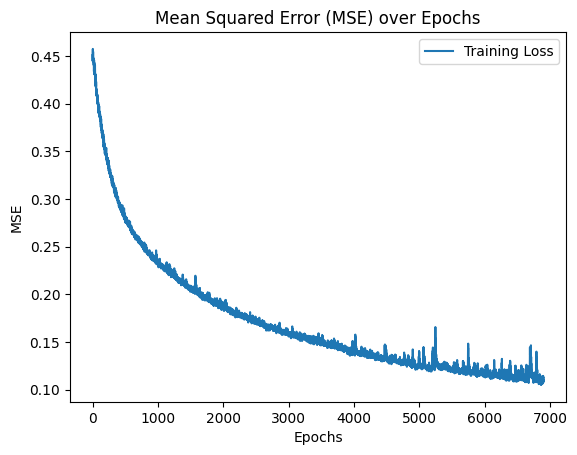

Test MSE: 0.04229790273726554
R^2: 0.6563738387080973


In [6]:
####################    NN training and PREDICTION    #######################

print("\nLF Model:")

definition_LF={
        "network_type": "LF",
        "params": best_params,
        "data_train": reaction_LF,
        "output_train": U_LF,
        "N": NepoLF,
        "n": Nlf,
        "train": True,
        "do_HPO": False,
        "verbose": False
    }


model= NetworkFactory.build_network(**definition_LF)
ULF = model.prediction(reaction_LF_test_original)

(mse_LF,R_LF) = model.performance(reaction_LF_test_original,U_LF_test_original)


## High Fidelity data

In [7]:

file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

# correspondent U value in the HF scenario
U_HF_test = U_HF_test[
    :, -1, 44,44
]

U_HF_test = normalization(U_HF_test)
reaction_HF_test = normalization(reaction_HF_test)
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

UHF = model.prediction(reaction_HF_test_original)
(mse_HF,R_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)


Test MSE: 0.1619004091371321
R^2: -0.43023095419023427


# Plot

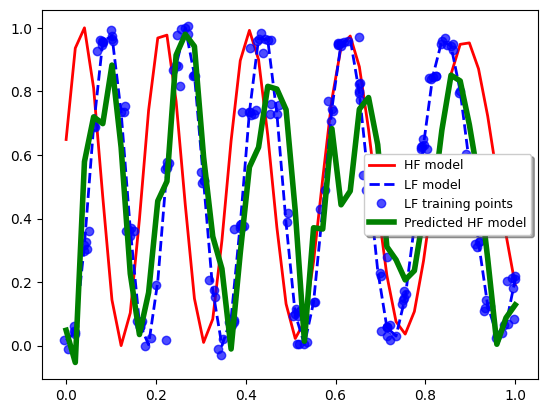

In [16]:
plt.figure()

# HF model line
plt.plot(reaction_HF_test[:,0], U_HF_test, "r-", linewidth=2, label="HF model")

# LF model line (dashed)
plt.plot(reaction_LF_test_original[:,0], U_LF_test_original, "b--", linewidth=2, label="LF model")

# LF training points (blue circles)
plt.plot(
    reaction_LF[:,0],
    U_LF,
    "bo",
    markersize=6,
    alpha=0.7,  # slightly transparent for better visibility
    label="LF training points",
)

# Predicted HF model (thicker green line)
plt.plot(
    reaction_HF_test_original[:,0],
    model.prediction(reaction_HF_test_original),
    "g-",
    linewidth=4,  # thicker line for emphasis
    label="Predicted HF model",
)

# Adjusting the legend to ensure it is clear
plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=True, shadow=True)

plt.show()

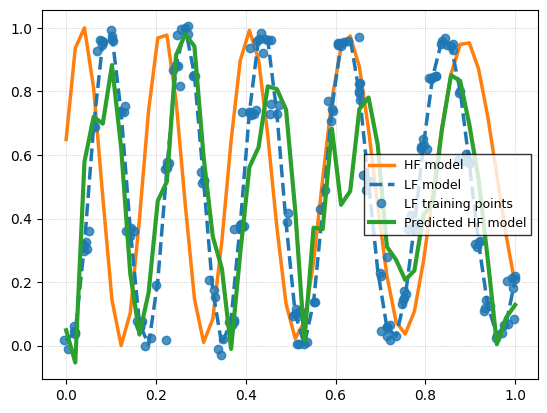

In [18]:
plt.figure()

# HF model line: spessa e arancione
plt.plot(reaction_HF_test[:,0], U_HF_test, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

# LF model line: tratteggiata e blu
plt.plot(reaction_LF_test_original[:,0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

# LF training points: stessi colore della linea LF (blu)
plt.plot(
    reaction_LF[:,0],
    U_LF,
    "o",
    markersize=6,
    color="#1F77B4",
    markeredgewidth=1,
    alpha=0.8,
    label="LF training points",
)

# Predicted HF model: linea verde senza quadrati, più sottile
plt.plot(
    reaction_HF_test_original[:,0],
    model.prediction(reaction_HF_test_original),
    color="#2CA02C",
    linestyle="-",
    linewidth=3,
    label="Predicted HF model",
)

# Legenda migliorata, con stile semplice
plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")

# Griglia leggera e minimale
plt.grid(True, which='both', linestyle=':', linewidth=0.5)

plt.show()

In [ ]:

#########################     SAVE the OUTPUT      ##########################
os.makedirs("NNLF_LF200_7000_noise_fourier")

R2_HF = pandas.DataFrame({"R2_HF": [R_HF]})
R2_LF = pandas.DataFrame({"R2_LF": [R_LF]})
MSE_test_LF = pandas.DataFrame({"MSE_test_LF": [mse_LF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [mse_HF]})


R2_LF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/r2_HF.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
MSE_test_HF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
MSE_test_LF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)